In [2]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/ex1/eventos_espera_semana_nuevo.csv", delimiter=",")
df

,ICAO,ultimo_parado,despegue,tiempo_espera,aircraft_type,lat,lon,holding_point,fecha_despegue,hora_despegue,runway
0,3420ca,2024-12-03 15:21:22.843,2024-12-03 15:23:03.503,100.660,Medium 2 (between 34000 kg to 136000 kg),40.505962,-3.559235,Y2,2024-12-03,15,18L/36R
1,3420ca,2024-12-04 09:24:55.891,2024-12-04 09:26:36.177,100.286,Medium 2 (between 34000 kg to 136000 kg),40.504462,-3.559211,Y1,2024-12-04,9,18L/36R
2,3420ca,2024-12-04 16:16:10.860,2024-12-04 16:17:46.200,95.340,Medium 2 (between 34000 kg to 136000 kg),40.498638,-3.574646,Z4,2024-12-04,16,18R/36L
3,3420ca,2024-12-07 20:14:55.509,2024-12-07 20:16:48.101,112.592,Medium 2 (between 34000 kg to 136000 kg),40.504613,-3.559211,Y1,2024-12-07,20,18L/36R
4,3444c3,2024-12-02 14:42:10.407,2024-12-02 14:43:51.726,101.319,Medium 2 (between 34000 kg to 136000 kg),40.505824,-3.559227,Y1,2024-12-02,14,18L/36R
...,...,...,...,...,...,...,...,...,...,...,...
1291,345597,2024-12-04 11:59:33.506,2024-12-04 12:02:01.348,147.842,Medium 2 (between 34000 kg to 136000 kg),40.498341,-3.574646,Z4,2024-12-04,12,18R/36L
1292,345597,2024-12-05 14:56:14.304,2024-12-05 14:56:48.566,34.262,Medium 2 (between 34000 kg to 136000 kg),40.500057,-3.559464,Y1,2024-12-05,14,18L/36R
1293,345597,2024-12-06 16:11:57.714,2024-12-06 16:13:59.680,121.966,Medium 2 (between 34000 kg to 136000 kg),40.498829,-3.574661,Z4,2024-12-06,16,18R/36L
1294,4d22b1,2024-12-07 19:23:06.400,2024-12-07 19:25:05.533,119.133,Medium 2 (between 34000 kg to 136000 kg),40.505672,-3.559243,Y1,2024-12-07,19,18L/36R


In [3]:
df.columns

Index(['ICAO', 'ultimo_parado', 'despegue', 'tiempo_espera', 'aircraft_type',
       'lat', 'lon', 'holding_point', 'fecha_despegue', 'hora_despegue',
       'runway'],
      dtype='object')

In [4]:
df = df.dropna().reset_index(drop=True)

In [5]:
df["holding_point"].unique()

array(['Y2', 'Y1', 'Z4', 'Z2', 'Z3', 'Z1', 'KA6', 'LB', 'K2', 'LC', 'Z6',
       'LE', 'LD', 'Y3', 'LA', 'KA8', 'K1'], dtype=object)

In [6]:
df.dtypes

ICAO               object
ultimo_parado      object
despegue           object
tiempo_espera     float64
aircraft_type      object
lat               float64
lon               float64
holding_point      object
fecha_despegue     object
hora_despegue       int64
runway             object
dtype: object

In [7]:
icaos = df[["ICAO","tiempo_espera"]]
df.head()

,ICAO,ultimo_parado,despegue,tiempo_espera,aircraft_type,lat,lon,holding_point,fecha_despegue,hora_despegue,runway
0,3420ca,2024-12-03 15:21:22.843,2024-12-03 15:23:03.503,100.660,Medium 2 (between 34000 kg to 136000 kg),40.505962,-3.559235,Y2,2024-12-03,15,18L/36R
1,3420ca,2024-12-04 09:24:55.891,2024-12-04 09:26:36.177,100.286,Medium 2 (between 34000 kg to 136000 kg),40.504462,-3.559211,Y1,2024-12-04,9,18L/36R
2,3420ca,2024-12-04 16:16:10.860,2024-12-04 16:17:46.200,95.340,Medium 2 (between 34000 kg to 136000 kg),40.498638,-3.574646,Z4,2024-12-04,16,18R/36L
3,3420ca,2024-12-07 20:14:55.509,2024-12-07 20:16:48.101,112.592,Medium 2 (between 34000 kg to 136000 kg),40.504613,-3.559211,Y1,2024-12-07,20,18L/36R
4,3444c3,2024-12-02 14:42:10.407,2024-12-02 14:43:51.726,101.319,Medium 2 (between 34000 kg to 136000 kg),40.505824,-3.559227,Y1,2024-12-02,14,18L/36R


In [8]:
## Cargar bien los tiempos
timestap_columns = ["ultimo_parado","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
ultimo_parado     datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
lat                      float64
lon                      float64
holding_point             object
fecha_despegue    datetime64[ns]
hora_despegue              int64
runway                    object
dtype: object

In [9]:
df.sort_values("ultimo_parado")

,ICAO,ultimo_parado,despegue,tiempo_espera,aircraft_type,lat,lon,holding_point,fecha_despegue,hora_despegue,runway
217,aac33e,2024-12-01 00:38:08.329,2024-12-01 00:39:48.750,100.421,Heavy (larger than 136000 kg),40.497735,-3.574645,Z1,2024-12-01,0,18R/36L
533,4cada6,2024-12-01 04:59:49.165,2024-12-01 05:00:56.920,67.755,Medium 2 (between 34000 kg to 136000 kg),40.498247,-3.574645,Z2,2024-12-01,5,18R/36L
15,4ca75f,2024-12-01 05:00:43.211,2024-12-01 05:02:49.620,126.409,Medium 2 (between 34000 kg to 136000 kg),40.498538,-3.574645,Z4,2024-12-01,5,18R/36L
911,4ca225,2024-12-01 05:24:47.645,2024-12-01 05:26:49.631,121.986,Medium 2 (between 34000 kg to 136000 kg),40.498123,-3.574646,Z2,2024-12-01,5,18R/36L
64,4ca2c0,2024-12-01 05:26:45.264,2024-12-01 05:28:43.020,117.756,Medium 2 (between 34000 kg to 136000 kg),40.497826,-3.574646,Z2,2024-12-01,5,18R/36L
...,...,...,...,...,...,...,...,...,...,...,...
280,8964c3,2024-12-07 20:28:29.504,2024-12-07 20:29:46.648,77.144,Heavy (larger than 136000 kg),40.504509,-3.559211,Y1,2024-12-07,20,18L/36R
527,06a2f2,2024-12-07 21:10:20.045,2024-12-07 21:11:43.880,83.835,Heavy (larger than 136000 kg),40.507081,-3.559227,Y3,2024-12-07,21,18L/36R
9,346188,2024-12-07 22:02:14.048,2024-12-07 22:04:48.160,154.112,Medium 2 (between 34000 kg to 136000 kg),40.496521,-3.574814,Z4,2024-12-07,22,18R/36L
371,345686,2024-12-07 22:08:30.532,2024-12-07 22:10:10.102,99.570,Medium 2 (between 34000 kg to 136000 kg),40.497118,-3.574817,Z4,2024-12-07,22,18R/36L


In [10]:
df.groupby("fecha_despegue")["ICAO"]

In [11]:
categorical_columns = df.select_dtypes("object")
categorical_columns.columns.drop("ICAO")

Index(['aircraft_type', 'holding_point', 'runway'], dtype='object')

In [12]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop("ICAO")

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = categorical_columns)
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [13]:
def calcular_tiempo_relativo(tiempo_referencia,tiempo_fila):
    tiempo_referencia_segundos = tiempo_referencia.timestamp()
    tiempo_fila_segundos = tiempo_fila.timestamp()
    return (tiempo_referencia_segundos - tiempo_fila_segundos)

In [14]:
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()
df_encoded_sorted

,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,230,34510a,2024-12-06 13:46:55.232,2024-12-07 23:22:51.394,120956.162,40.498260,-3.574646,2024-12-07,23,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,672,4cad3d,2024-12-07 23:14:53.199,2024-12-07 23:17:51.093,177.894,40.497153,-3.574630,2024-12-07,23,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,371,345686,2024-12-07 22:08:30.532,2024-12-07 22:10:10.102,99.570,40.497118,-3.574817,2024-12-07,22,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,9,346188,2024-12-07 22:02:14.048,2024-12-07 22:04:48.160,154.112,40.496521,-3.574814,2024-12-07,22,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,527,06a2f2,2024-12-07 21:10:20.045,2024-12-07 21:11:43.880,83.835,40.507081,-3.559227,2024-12-07,21,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,64,4ca2c0,2024-12-01 05:26:45.264,2024-12-01 05:28:43.020,117.756,40.497826,-3.574646,2024-12-01,5,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1291,911,4ca225,2024-12-01 05:24:47.645,2024-12-01 05:26:49.631,121.986,40.498123,-3.574646,2024-12-01,5,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1292,15,4ca75f,2024-12-01 05:00:43.211,2024-12-01 05:02:49.620,126.409,40.498538,-3.574645,2024-12-01,5,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1293,533,4cada6,2024-12-01 04:59:49.165,2024-12-01 05:00:56.920,67.755,40.498247,-3.574645,2024-12-01,5,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


{'whiskers': [<matplotlib.lines.Line2D at 0x144749220>,
 'caps': [<matplotlib.lines.Line2D at 0x144749730>,
 'boxes': [<matplotlib.lines.Line2D at 0x144748e90>],
 'medians': [<matplotlib.lines.Line2D at 0x144749d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x14474a0c0>],
 'means': []}

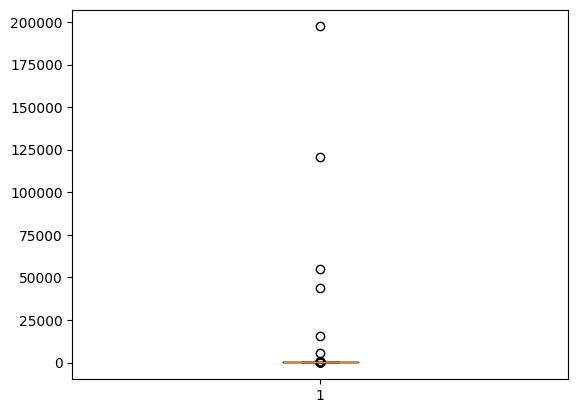

In [15]:
import matplotlib.pyplot as plt

plt.boxplot(df_encoded_sorted["tiempo_espera"])

In [16]:
Q1 = df_encoded_sorted['tiempo_espera'].quantile(0.25)  # Primer cuartil
Q3 = df_encoded_sorted['tiempo_espera'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1  # Rango intercuartílico

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores dentro de los límites
df_sin_outliers = df_encoded_sorted[(df_encoded_sorted['tiempo_espera'] >= limite_inferior) & (df_encoded_sorted['tiempo_espera'] <= limite_superior)]

print("DataFrame sin outliers:")
df_sin_outliers.head()

DataFrame sin outliers:


,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
1,672,4cad3d,2024-12-07 23:14:53.199,2024-12-07 23:17:51.093,177.894,40.497153,-3.574630,2024-12-07,23,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,371,345686,2024-12-07 22:08:30.532,2024-12-07 22:10:10.102,99.570,40.497118,-3.574817,2024-12-07,22,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,9,346188,2024-12-07 22:02:14.048,2024-12-07 22:04:48.160,154.112,40.496521,-3.574814,2024-12-07,22,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,527,06a2f2,2024-12-07 21:10:20.045,2024-12-07 21:11:43.880,83.835,40.507081,-3.559227,2024-12-07,21,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,280,8964c3,2024-12-07 20:28:29.504,2024-12-07 20:29:46.648,77.144,40.504509,-3.559211,2024-12-07,20,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<Axes: >

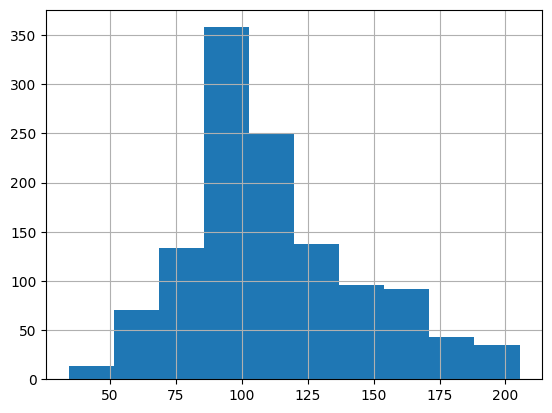

In [17]:
df_sin_outliers["tiempo_espera"].hist()

In [31]:
df_sin_outliers["tiempo_espera"].describe()

count    1230.000000
mean      112.067364
std        32.735820
min        34.262000
25%        90.839250
50%       104.792500
75%       129.450250
max       205.367000
Name: tiempo_espera, dtype: float64

In [32]:
df_predict = df_encoded_sorted.drop(columns = ["index","ICAO","ultimo_parado","despegue","fecha_despegue","hora_despegue"])
print(df_predict)

      tiempo_espera        lat       lon  \
0        120956.162  40.498260 -3.574646   
1           177.894  40.497153 -3.574630   
2            99.570  40.497118 -3.574817   
3           154.112  40.496521 -3.574814   
4            83.835  40.507081 -3.559227   
...             ...        ...       ...   
1290        117.756  40.497826 -3.574646   
1291        121.986  40.498123 -3.574646   
1292        126.409  40.498538 -3.574645   
1293         67.755  40.498247 -3.574645   
1294        100.421  40.497735 -3.574645   

      aircraft_type_Heavy (larger than 136000 kg)  \
0                                             1.0   
1                                             0.0   
2                                             0.0   
3                                             0.0   
4                                             1.0   
...                                           ...   
1290                                          0.0   
1291                                          0

In [33]:

X = df_predict.drop(columns=["tiempo_espera"])
y = df_predict["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar los datos de entrada
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Construcción del modelo
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Capa de salida sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test))

# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")


Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34174068.0000 - mae: 387.1428 - val_loss: 148963.7344 - val_mae: 141.3243
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - loss: 62410668.0000 - mae: 651.0569 - val_loss: 146673.1094 - val_mae: 132.2345
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - loss: 51713172.0000 - mae: 503.9615 - val_loss: 142144.2344 - val_mae: 112.3331
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 39482388.0000 - mae: 480.3475 - val_loss: 135617.0156 - val_mae: 77.7572
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - loss: 60577988.0000 - mae: 484.8883 - val_loss: 130744.9766 - val_mae: 54.4755
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 22063132.0000 - mae: 269.8747 - val_loss: 129110.8438 - val_mae: 54.6411
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 51007340.0000 - mae: 342.6052 - val_loss: 128549.5781 - val_mae: 59.1302
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 20255140.000

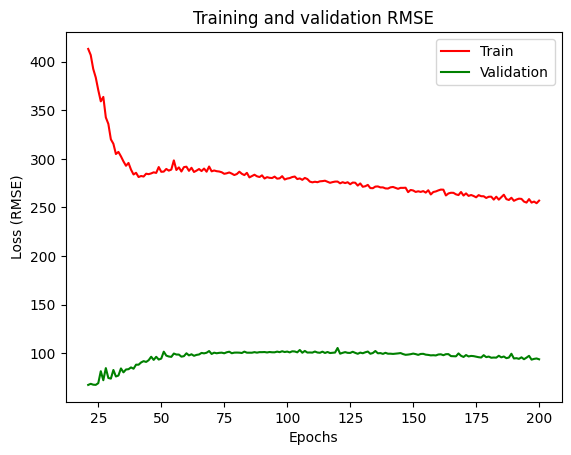

In [34]:
import matplotlib.pyplot as plt

loss = history.history['mae']
val_loss = history.history['val_mae']

epochs = range(1, len(loss) + 1)

plt.plot(epochs[20:], loss[20:], 'r', label='Train')
plt.plot(epochs[20:], val_loss[20:], 'g', label='Validation')

plt.title('Training and validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')
plt.legend()

plt.show()

In [13]:
df_lista = []
for indice, fila in df_encoded_sorted.iterrows():
    if indice < len(df_encoded_sorted) - 1:  # Verificar que no sea el último índice
        tiempo_referencia = fila["despegue"]
        
        # Seleccionar solo las filas a partir del índice
        tiempos= df_encoded_sorted.iloc[indice:].apply(
            lambda row: calcular_tiempo_relativo(tiempo_referencia, row["despegue"]), axis=1)
        
        # Filtrar el DataFrame en función de la columna 'ventana'
        ##df_filter = df_encoded_sorted[(df_encoded_sorted["ventana"] <= 1800)]
    
        tiempos = tiempos[tiempos <=1800]
   
        df_concat = pd.concat([df_encoded_sorted.iloc[indice: indice + len(tiempos)],tiempos],axis =1)
        df_lista.append(df_concat)


In [20]:
df_lista[16]

,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,runway_nan,0
16,1294,4d22b1,2024-12-07 19:23:06.400,2024-12-07 19:25:05.533,119.133,40.505672,-3.559243,2024-12-07,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000
17,378,346082,2024-12-07 19:22:52.903,2024-12-07 19:24:28.367,95.464,40.495846,-3.574646,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,37.166
18,1049,3472c9,2024-12-07 19:21:22.609,2024-12-07 19:22:57.972,95.363,40.497448,-3.574677,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,127.561
19,918,3451da,2024-12-07 19:19:28.541,2024-12-07 19:21:34.394,125.853,40.497723,-3.574646,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,211.139
20,214,347648,2024-12-07 19:18:11.059,2024-12-07 19:19:54.912,103.853,40.494358,-3.574631,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,310.621
21,604,3451d9,2024-12-07 19:03:19.564,2024-12-07 19:04:42.408,82.844,40.499222,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1223.125
22,467,345698,2024-12-07 18:58:30.030,2024-12-07 19:02:17.756,227.726,40.499474,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1367.777
23,649,344216,2024-12-07 18:57:21.751,2024-12-07 19:00:47.118,205.367,40.499817,-3.574692,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1458.415


In [244]:
for i, df in enumerate(df_lista):
    df.to_csv(f"/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/dataframe_{i}.csv", index=False)